In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import seaborn as sns
from scipy.interpolate import CubicSpline  # Import CubicSpline for smooth curves
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

Import the metrics file

In [2]:
wandb.init(project="Parcel Delivery", name="user_val_data_graph_logging_run_460epochs")
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_4/metrics.csv"
metrics_data = pd.read_csv(file_path)

# Print available columns to verify
print("Available columns:", metrics_data.columns)


Available columns: Index(['train_precision_step', 'epoch', 'step', 'train_loss_step',
       'train_accuracy_step', 'lr-AdamW', 'val_best_f1/user_6',
       'val_loss/user_7', 'val_loss/user_4', 'val_recall',
       ...
       'train_loss/user_1', 'train_loss/user_8', 'train_best_f1/user_10',
       'train_loss/user_2', 'train_precision/user_4', 'train_loss/user_9',
       'train_best_f1/user_7', 'train_precision/user_1',
       'train_best_f1/user_9', 'train_loss/user_4'],
      dtype='object', length=125)


Plot various metrics vs epoch for each user

Getting only the columns of metrics of each users and epochs from csv file

In [3]:
# Check if both 'epoch' and 'val_loss/user_1' columns exist
if 'epoch' in metrics_data.columns and 'val_loss/user_1' in metrics_data.columns:
    # Filter the DataFrame for 'epoch' and 'val_loss/user_1'
    filtered_df_user_1 = metrics_data[['epoch', 'val_loss/user_0', 'val_loss/user_1', 'val_loss/user_2', 
                                       'val_loss/user_3', 'val_loss/user_4', 'val_loss/user_5', 
                                       'val_loss/user_6', 'val_loss/user_7', 'val_loss/user_8', 
                                       'val_loss/user_9', 'val_loss/user_10', 'val_loss/user_11', 
                                       'val_loss/user_12']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_loss_user_1 = filtered_df_user_1.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch' and 'val_loss/user_1':\n", distinct_epochs_and_loss_user_1)
else:
    print("Either 'epoch' or 'val_loss/user_1' column is not available in the DataFrame.")


Distinct values of 'epoch' and 'val_loss/user_1':
        epoch  val_loss/user_0  val_loss/user_1  val_loss/user_2  \
210      0.0         1.713035         0.815888         0.820508   
422      1.0         1.641751         0.843320         0.850258   
634      2.0         1.562148         0.877685         0.887088   
846      3.0         1.517407         0.896459         0.906690   
1058     4.0         1.476078         0.907175         0.918933   
...      ...              ...              ...              ...   
96882  456.0         0.003833         0.001092         0.000687   
97094  457.0         0.004090         0.001163         0.000691   
97306  458.0         0.004099         0.001161         0.000681   
97518  459.0         0.004716         0.001209         0.000689   
97730  460.0         0.005101         0.000989         0.000654   

       val_loss/user_3  val_loss/user_4  val_loss/user_5  val_loss/user_6  \
210           0.973414         1.876008         1.939973         1.

# Loss vs Epochs (for each users)

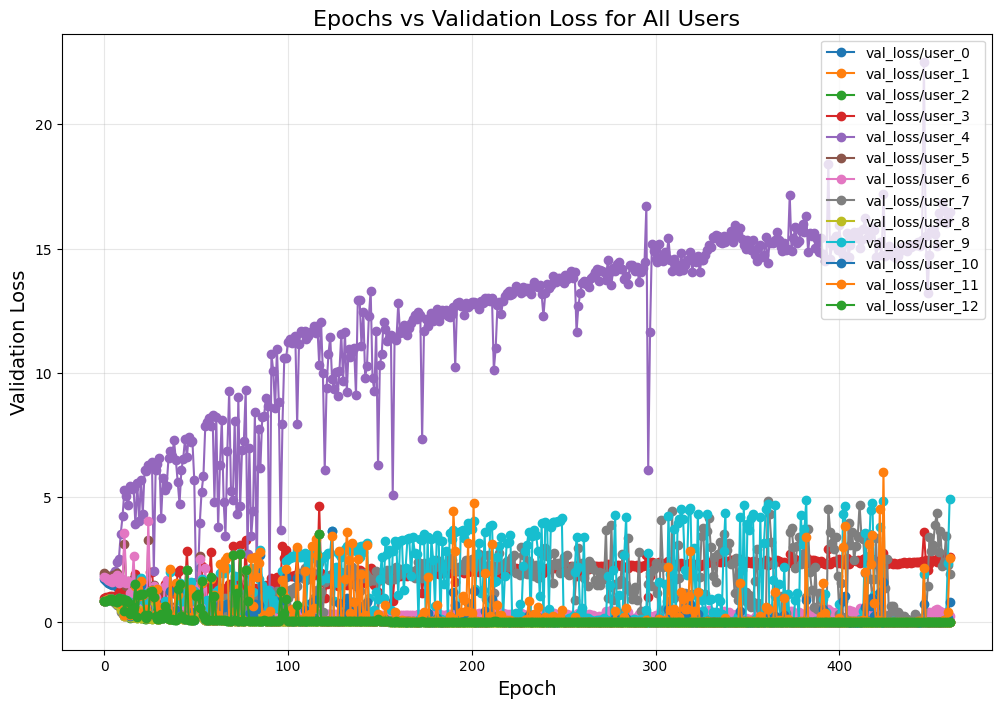

In [4]:
# Assuming the DataFrame is already loaded as metrics_df
# Check if 'epoch' exists and at least one user loss column exists
loss_columns = [
    'val_loss/user_0', 'val_loss/user_1', 'val_loss/user_2', 
    'val_loss/user_3', 'val_loss/user_4', 'val_loss/user_5', 
    'val_loss/user_6', 'val_loss/user_7', 'val_loss/user_8', 
    'val_loss/user_9', 'val_loss/user_10', 'val_loss/user_11', 
    'val_loss/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in loss_columns):
    # Filter the DataFrame for 'epoch' and all loss columns
    filtered_df = metrics_data[['epoch'] + loss_columns].dropna()
    
    # Plot each user's loss against epoch
    plt.figure(figsize=(12, 8))
    for loss_col in loss_columns:
        if loss_col in filtered_df.columns:
            plt.plot(filtered_df['epoch'], filtered_df[loss_col], marker='o', linestyle='-', label=loss_col)
    
    # Customize plot
    plt.title("Epochs vs Validation Loss for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Loss", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10, loc='upper right')
    
    # Log the plot to wandb
    wandb.log({"Individual User Validation Loss": wandb.Image(plt)})
    
    plt.show()
else:
    print("Either 'epoch' column or user loss columns are not available in the DataFrame.")


# Loss vs Epoch (Smooth) for each users

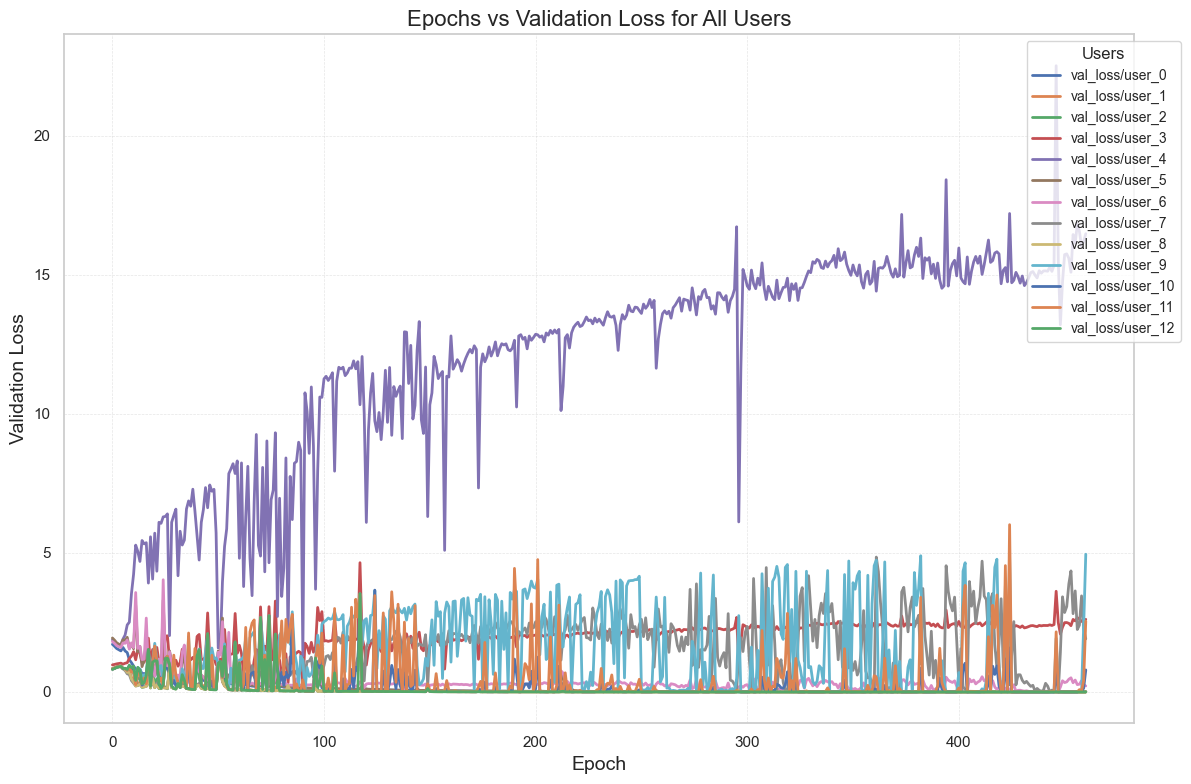

In [5]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user loss column exists
loss_columns = [
    'val_loss/user_0', 'val_loss/user_1', 'val_loss/user_2', 
    'val_loss/user_3', 'val_loss/user_4', 'val_loss/user_5', 
    'val_loss/user_6', 'val_loss/user_7', 'val_loss/user_8', 
    'val_loss/user_9', 'val_loss/user_10', 'val_loss/user_11', 
    'val_loss/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in loss_columns):
    # Filter the DataFrame for 'epoch' and all loss columns
    filtered_df = metrics_data[['epoch'] + loss_columns].dropna()
    
    # Set seaborn style for better aesthetics
    sns.set(style="whitegrid")

    # Initialize the plot
    plt.figure(figsize=(12, 8))

    # Plot each user's loss against epoch using seaborn's lineplot for smooth curves
    for loss_col in loss_columns:
        if loss_col in filtered_df.columns:
            sns.lineplot(x='epoch', y=loss_col, data=filtered_df, label=loss_col, lw=2)

    # Customize plot
    plt.title("Epochs vs Validation Loss for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Loss", fontsize=14)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Move the legend to the upper-right corner
    plt.legend(fontsize=10, loc='upper right', bbox_to_anchor=(1.05, 1), title="Users")

    # Log the image to wandb
    wandb.log({"Individual User Validation Loss (Smooth)": wandb.Image(plt)})

    # Show the plot
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

else:
    print("Either 'epoch' column or user loss columns are not available in the DataFrame.")


# Loss vs Epoch Subplot for each users

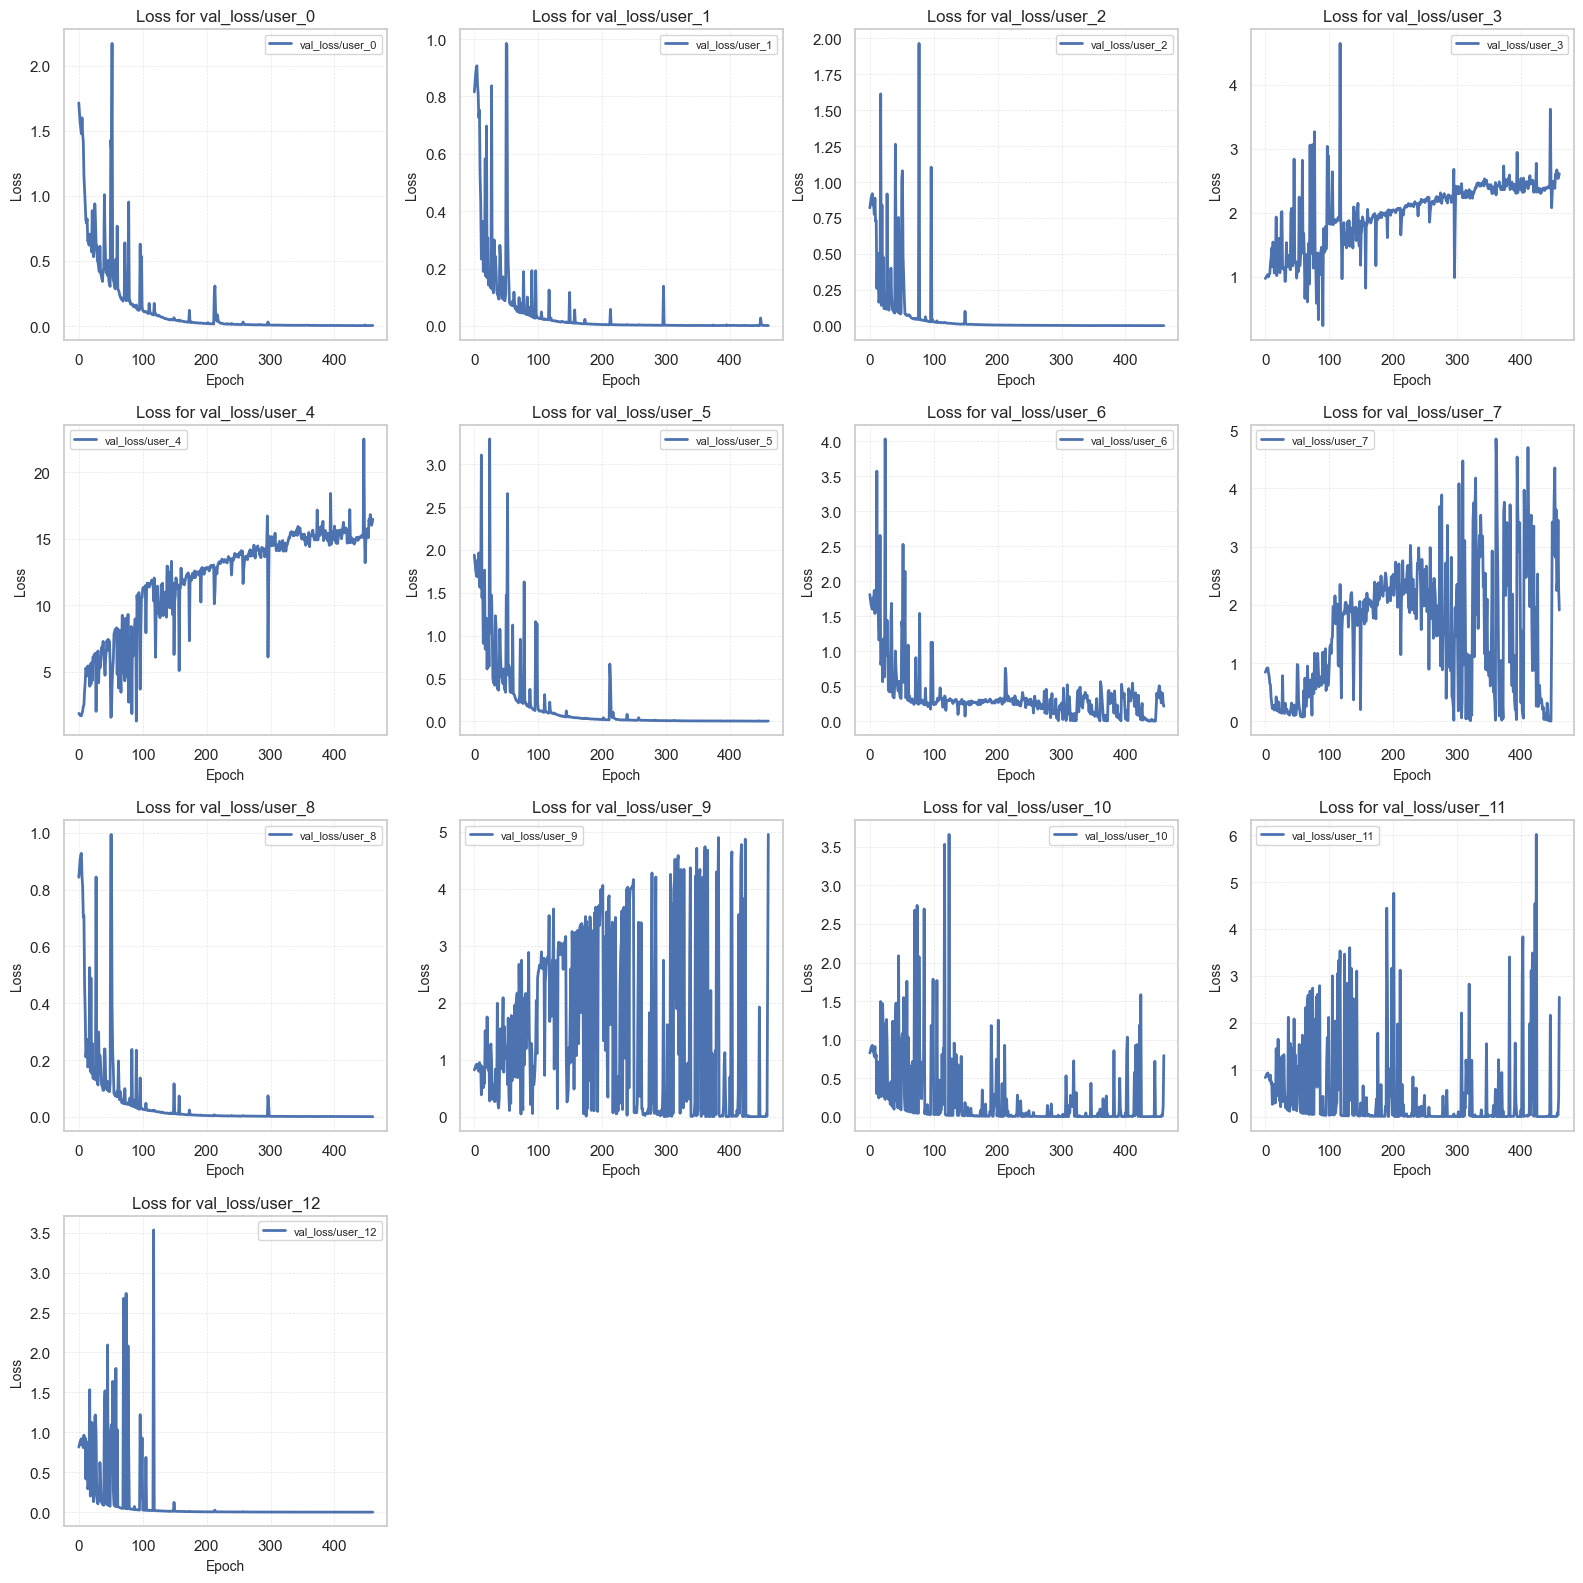

In [6]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user loss column exists
loss_columns = [
    'val_loss/user_0', 'val_loss/user_1', 'val_loss/user_2', 
    'val_loss/user_3', 'val_loss/user_4', 'val_loss/user_5', 
    'val_loss/user_6', 'val_loss/user_7', 'val_loss/user_8', 
    'val_loss/user_9', 'val_loss/user_10', 'val_loss/user_11', 
    'val_loss/user_12'
]

# Check if 'epoch' and any of the 'val_loss' columns are present
if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in loss_columns):
    # Filter the DataFrame for 'epoch' and all loss columns
    filtered_df = metrics_data[['epoch'] + loss_columns].dropna()

    # Set seaborn style for better aesthetics
    sns.set(style="whitegrid")

    # Determine the number of subplots (one for each user)
    num_users = len(loss_columns)
    rows = num_users // 4 + (num_users % 4 > 0)  # 4 plots per row, adjust number of rows

    # Create the subplots
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
    
    # Flatten the axes array to easily iterate over it
    axes = axes.flatten()

    # Plot each user's loss against epoch in a separate subplot
    for i, loss_col in enumerate(loss_columns):
        if loss_col in filtered_df.columns:
            # Extract the user loss values
            x = filtered_df['epoch']
            y = filtered_df[loss_col]
        
            # Plot the loss values for the user in the respective subplot
            axes[i].plot(x, y, lw=2, label=loss_col)
        
            # Customize the subplot
            axes[i].set_title(f"Loss for {loss_col}", fontsize=12)
            axes[i].set_xlabel("Epoch", fontsize=10)
            axes[i].set_ylabel("Loss", fontsize=10)
            axes[i].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
            axes[i].legend(fontsize=8)

    # Hide unused subplots
    for j in range(len(loss_columns), len(axes)):
        axes[j].set_visible(False)

    # Adjust layout to avoid overlapping subplots
    plt.tight_layout()

    # Log the image to wandb
    wandb.log({"Individual User Validation Loss subplot": wandb.Image(fig)})

    # Show the plot
    plt.show()

else:
    print("Either 'epoch' column or user loss columns are not available in the DataFrame.")


In [7]:
# Check if both 'epoch' and 'val_recall/user_1' columns exist
if 'epoch' in metrics_data.columns and 'val_recall/user_1' in metrics_data.columns:
    # Filter the DataFrame for 'epoch' and 'val_recall/user_1'
    filtered_df_user_1 = metrics_data[['epoch', 'val_recall/user_0', 'val_recall/user_1', 
                                       'val_recall/user_2', 'val_recall/user_3', 'val_recall/user_4', 
                                       'val_recall/user_5', 'val_recall/user_6', 'val_recall/user_7', 
                                       'val_recall/user_8', 'val_recall/user_9', 'val_recall/user_10', 
                                       'val_recall/user_11', 'val_recall/user_12']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_recall_user_1 = filtered_df_user_1.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch' and 'val_recall/user_1':\n", distinct_epochs_and_recall_user_1)
else:
    print("Either 'epoch' or 'val_recall/user_1' column is not available in the DataFrame.")


Distinct values of 'epoch' and 'val_recall/user_1':
        epoch  val_recall/user_0  val_recall/user_1  val_recall/user_2  \
210      0.0           0.968750                0.0                0.0   
422      1.0           0.966346                0.0                0.0   
634      2.0           0.968750                0.0                0.0   
846      3.0           0.968750                0.0                0.0   
1058     4.0           0.968750                0.0                0.0   
...      ...                ...                ...                ...   
96882  456.0           1.000000                0.0                0.0   
97094  457.0           1.000000                0.0                0.0   
97306  458.0           1.000000                0.0                0.0   
97518  459.0           1.000000                0.0                0.0   
97730  460.0           1.000000                0.0                0.0   

       val_recall/user_3  val_recall/user_4  val_recall/user_5  \
210 

# Train Recall vs Epoch (for each users)

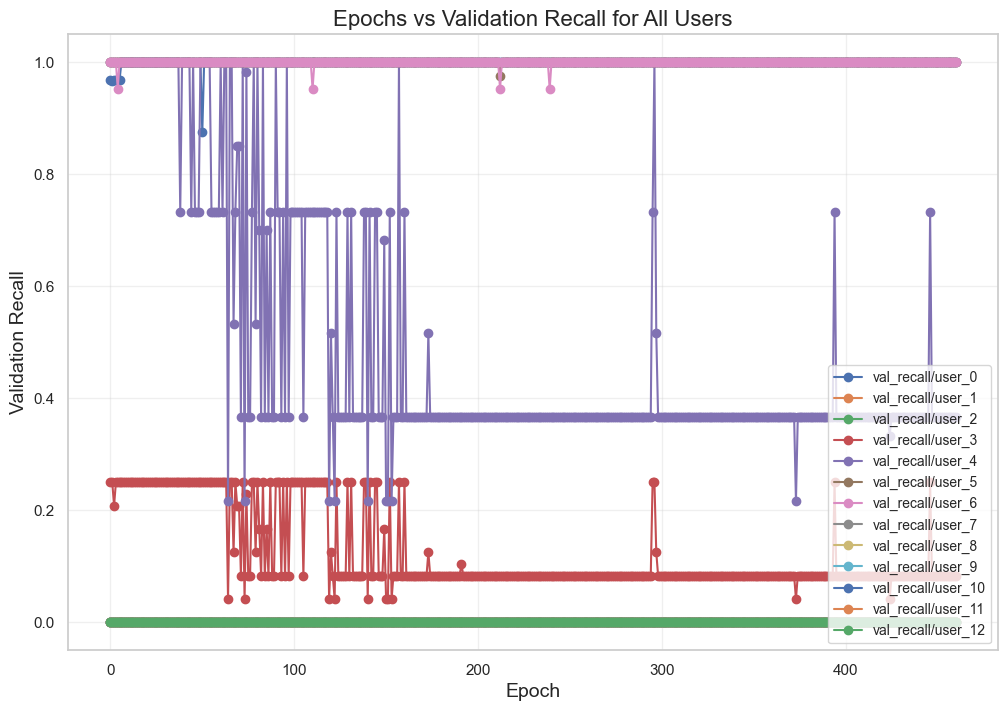

In [8]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user recall column exists
recall_columns = [
    'val_recall/user_0', 'val_recall/user_1', 'val_recall/user_2', 
    'val_recall/user_3', 'val_recall/user_4', 'val_recall/user_5', 
    'val_recall/user_6', 'val_recall/user_7', 'val_recall/user_8', 
    'val_recall/user_9', 'val_recall/user_10', 'val_recall/user_11', 
    'val_recall/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in recall_columns):
    # Filter the DataFrame for 'epoch' and all recall columns
    filtered_df = metrics_data[['epoch'] + recall_columns].dropna()
    
    # Plot each user's recall against epoch
    plt.figure(figsize=(12, 8))
    for recall_col in recall_columns:
        if recall_col in filtered_df.columns:
            plt.plot(filtered_df['epoch'], filtered_df[recall_col], marker='o', linestyle='-', label=recall_col)
    
    # Customize plot
    plt.title("Epochs vs Validation Recall for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Recall", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10, loc='lower right')
    
    # Log the figure to wandb (optional)
    wandb.log({"Individual User Validation Recall": wandb.Image(plt)})
    
    plt.show()
else:
    print("Either 'epoch' column or user recall columns are not available in the DataFrame.")


# Smooth Train Recall vs Epoch (For each users)

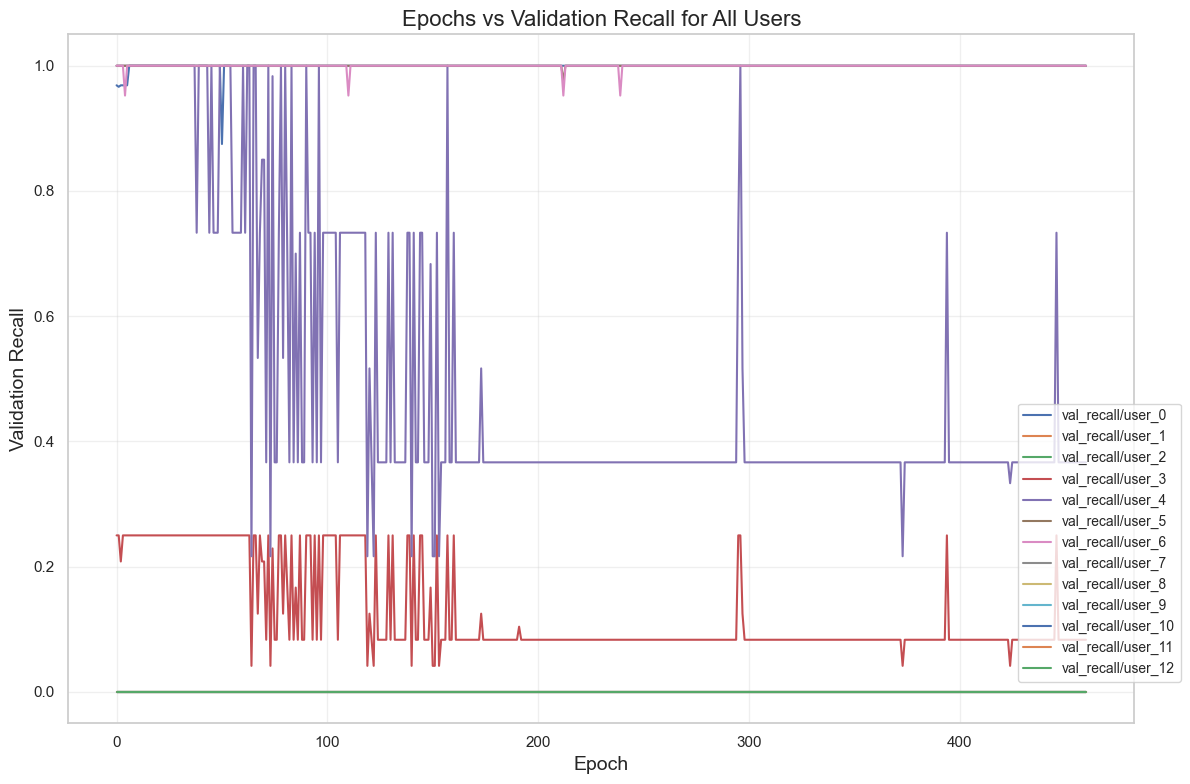

In [9]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user recall column exists
recall_columns = [
    'val_recall/user_0', 'val_recall/user_1', 'val_recall/user_2', 
    'val_recall/user_3', 'val_recall/user_4', 'val_recall/user_5', 
    'val_recall/user_6', 'val_recall/user_7', 'val_recall/user_8', 
    'val_recall/user_9', 'val_recall/user_10', 'val_recall/user_11', 
    'val_recall/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in recall_columns):
    # Filter the DataFrame for 'epoch' and all recall columns
    filtered_df = metrics_data[['epoch'] + recall_columns].dropna()
    
    # Plot each user's recall against epoch using Seaborn's lineplot with smoothing
    plt.figure(figsize=(12, 8))
    for recall_col in recall_columns:
        if recall_col in filtered_df.columns:
            # Use Seaborn's lineplot with errorbar=None to avoid deprecation warnings
            sns.lineplot(x=filtered_df['epoch'], y=filtered_df[recall_col], label=recall_col, errorbar=None)
    
    # Customize plot
    plt.title("Epochs vs Validation Recall for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Recall", fontsize=14)
    plt.grid(alpha=0.3)
    
    # Adjust legend position to bottom-right
    plt.legend(fontsize=10, loc='lower right', bbox_to_anchor=(1.05, 0.05))
    
    # Log the figure to wandb (optional)
    wandb.log({"Individual User Validation Recall (Smooth)": wandb.Image(plt)})
    
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()
else:
    print("Either 'epoch' column or user recall columns are not available in the DataFrame.")


# Recall vs Epoch Subplot for each users

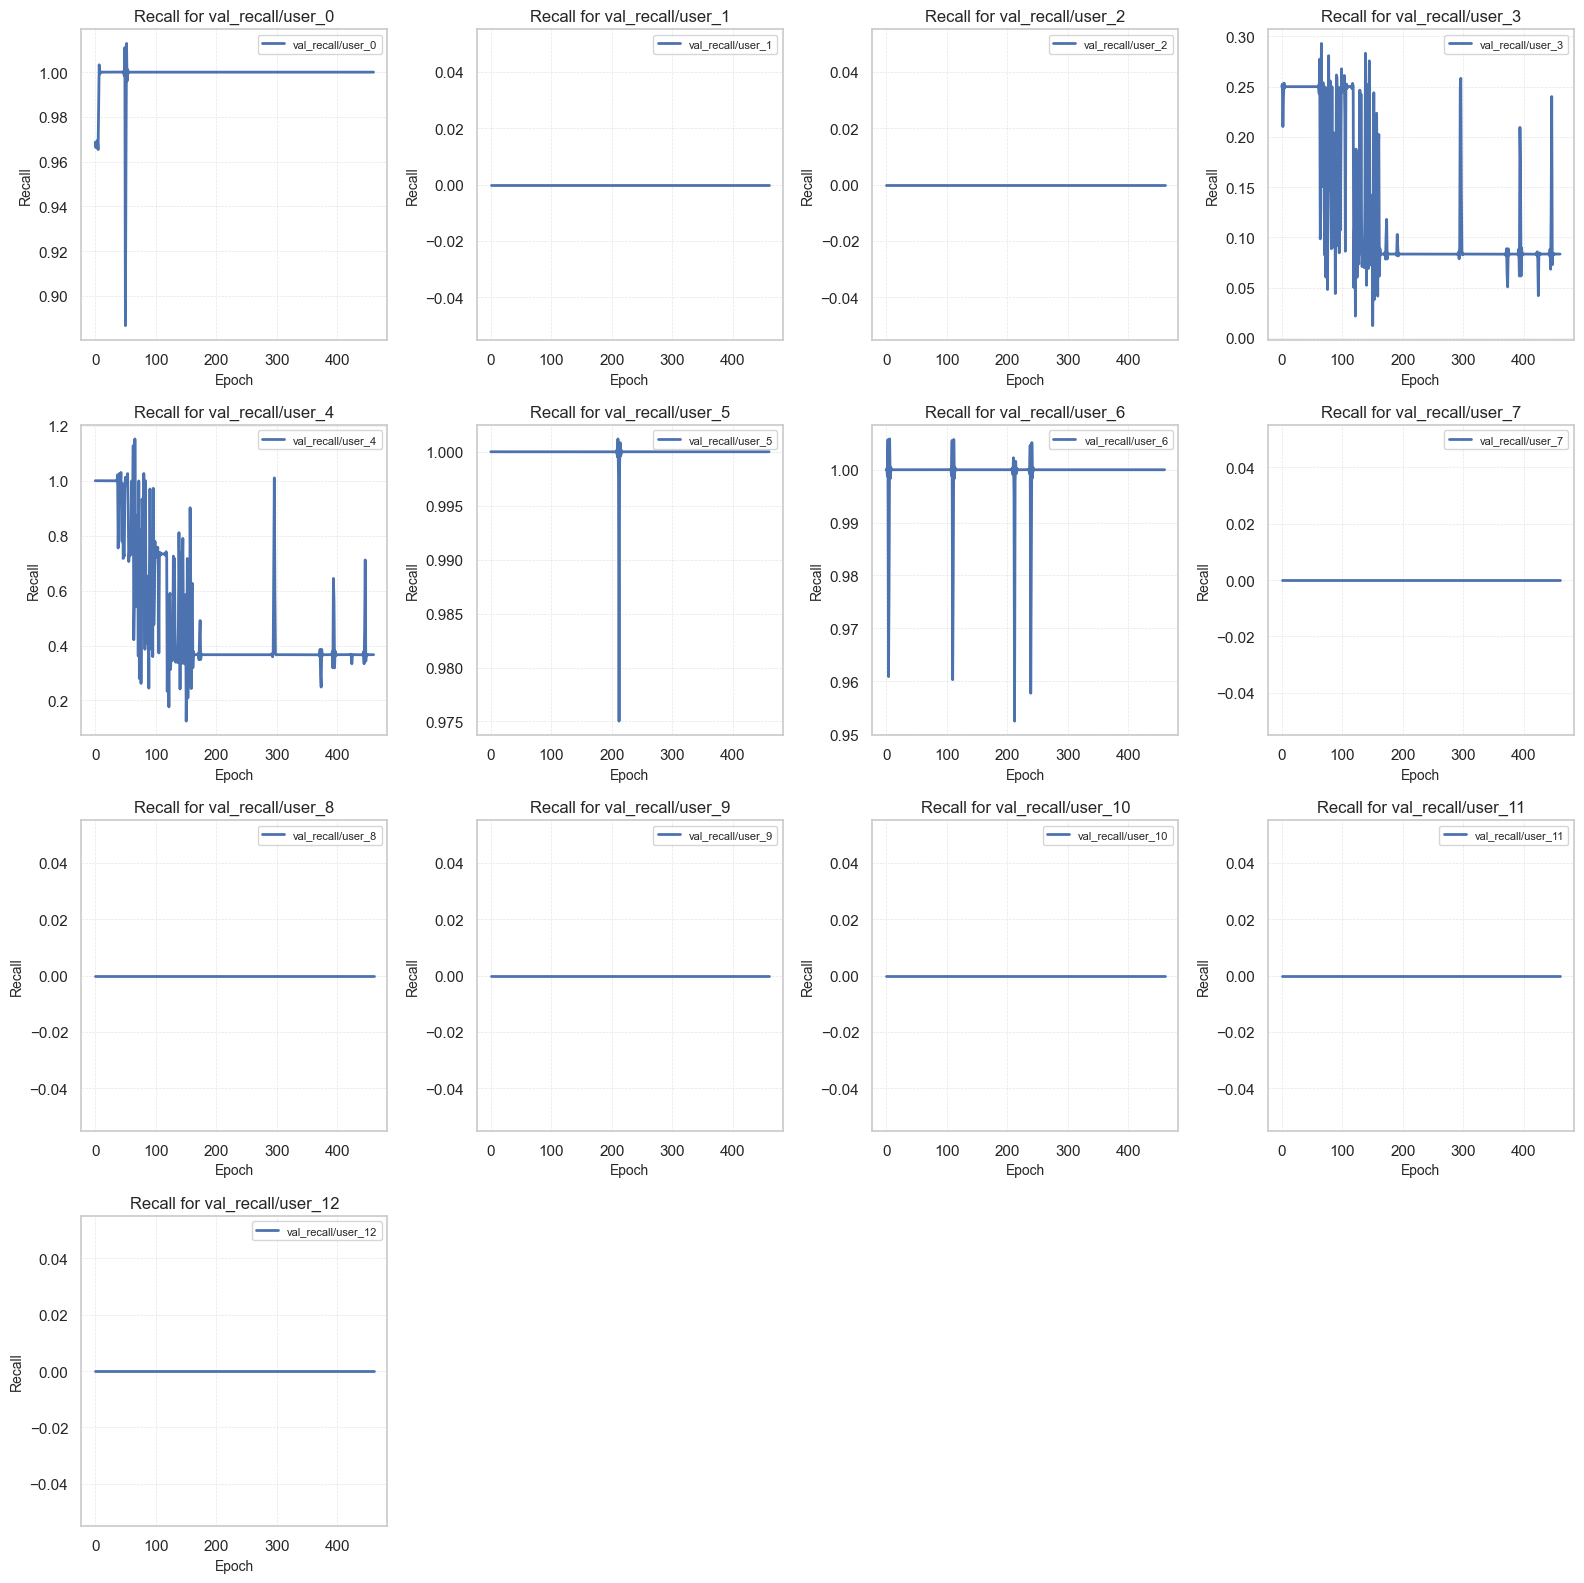

In [10]:
import numpy as np
from scipy.interpolate import CubicSpline

# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user recall column exists
recall_columns = [
    'val_recall/user_0', 'val_recall/user_1', 'val_recall/user_2', 
    'val_recall/user_3', 'val_recall/user_4', 'val_recall/user_5', 
    'val_recall/user_6', 'val_recall/user_7', 'val_recall/user_8', 
    'val_recall/user_9', 'val_recall/user_10', 'val_recall/user_11', 
    'val_recall/user_12'
]

# Check if 'epoch' and at least one recall column are present
if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in recall_columns):
    # Filter the DataFrame for 'epoch' and all recall columns
    filtered_df = metrics_data[['epoch'] + recall_columns].dropna()
    
    # Set seaborn style for better aesthetics
    sns.set(style="whitegrid")

    # Determine the number of subplots (one for each user)
    num_users = len(recall_columns)
    rows = num_users // 4 + (num_users % 4 > 0)  # 4 plots per row, adjust number of rows

    # Create the subplots
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
    
    # Flatten the axes array to easily iterate over it
    axes = axes.flatten()

    # Plot each user's recall against epoch in a separate subplot
    for i, recall_col in enumerate(recall_columns):
        if recall_col in filtered_df.columns:
            # Extract the user recall values
            x = filtered_df['epoch']
            y = filtered_df[recall_col]
        
            # Use cubic spline interpolation for smooth curves
            cs = CubicSpline(x, y, bc_type='natural')
        
            # Generate smooth values for plotting
            smooth_x = np.linspace(x.min(), x.max(), 500)  # More points for a smoother curve
            smooth_y = cs(smooth_x)
        
            # Plot the smooth line in the respective subplot
            axes[i].plot(smooth_x, smooth_y, lw=2, label=recall_col)
        
            # Customize the subplot
            axes[i].set_title(f"Recall for {recall_col}", fontsize=12)
            axes[i].set_xlabel("Epoch", fontsize=10)
            axes[i].set_ylabel("Recall", fontsize=10)
            axes[i].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
            axes[i].legend(fontsize=8)

    # Hide unused subplots
    for j in range(len(recall_columns), len(axes)):
        axes[j].set_visible(False)

    # Adjust layout to avoid overlapping subplots
    plt.tight_layout()

    # Log the image to wandb
    wandb.log({"Individual User Validation Recall Subplot": wandb.Image(fig)})

    # Show the plot
    plt.show()

else:
    print("Either 'epoch' column or user recall columns are not available in the DataFrame.")


In [11]:
# Check if both 'epoch' and 'val_best_f1/user_1' columns exist
if 'epoch' in metrics_data.columns and 'val_best_f1/user_1' in metrics_data.columns:
    # Filter the DataFrame for 'epoch' and 'val_best_f1/user_1'
    filtered_df_user_1 = metrics_data[['epoch', 'val_best_f1/user_0', 'val_best_f1/user_1', 
                                       'val_best_f1/user_2', 'val_best_f1/user_3', 'val_best_f1/user_4', 
                                       'val_best_f1/user_5', 'val_best_f1/user_6', 'val_best_f1/user_7', 
                                       'val_best_f1/user_8', 'val_best_f1/user_9', 'val_best_f1/user_10', 
                                       'val_best_f1/user_11', 'val_best_f1/user_12']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_best_f1_user_1 = filtered_df_user_1.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch' and 'val_best_f1/user_1':\n", distinct_epochs_and_best_f1_user_1)
else:
    print("Either 'epoch' or 'val_best_f1/user_1' column is not available in the DataFrame.")


Distinct values of 'epoch' and 'val_best_f1/user_1':
        epoch  val_best_f1/user_0  val_best_f1/user_1  val_best_f1/user_2  \
210      0.0            0.955882                 0.0                 0.0   
422      1.0            0.981959                 0.0                 0.0   
634      2.0            0.983333                 0.0                 0.0   
846      3.0            0.983333                 0.0                 0.0   
1058     4.0            0.983333                 0.0                 0.0   
...      ...                 ...                 ...                 ...   
96882  456.0            1.000000                 0.0                 0.0   
97094  457.0            1.000000                 0.0                 0.0   
97306  458.0            1.000000                 0.0                 0.0   
97518  459.0            1.000000                 0.0                 0.0   
97730  460.0            1.000000                 0.0                 0.0   

       val_best_f1/user_3  val_be

# Best f1 vs epoch (for each users)

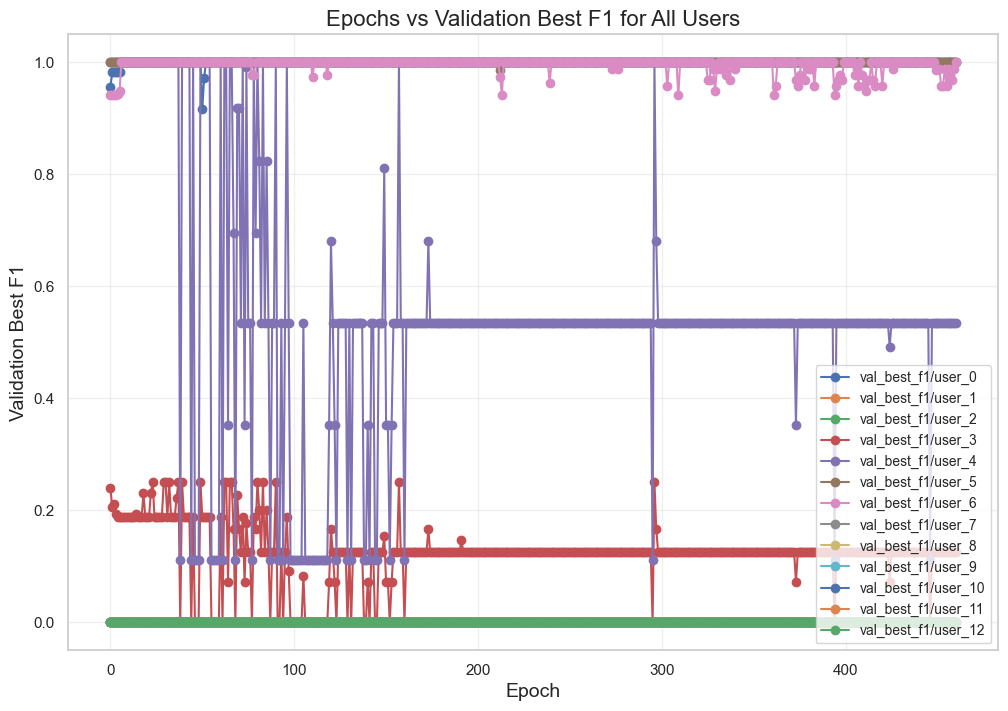

In [12]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user best_f1 column exists
best_f1_columns = [
    'val_best_f1/user_0', 'val_best_f1/user_1', 'val_best_f1/user_2', 
    'val_best_f1/user_3', 'val_best_f1/user_4', 'val_best_f1/user_5', 
    'val_best_f1/user_6', 'val_best_f1/user_7', 'val_best_f1/user_8', 
    'val_best_f1/user_9', 'val_best_f1/user_10', 'val_best_f1/user_11', 
    'val_best_f1/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in best_f1_columns):
    # Filter the DataFrame for 'epoch' and all best_f1 columns
    filtered_df = metrics_data[['epoch'] + best_f1_columns].dropna()
    
    # Plot each user's best_f1 against epoch
    plt.figure(figsize=(12, 8))
    for best_f1_col in best_f1_columns:
        if best_f1_col in filtered_df.columns:
            plt.plot(filtered_df['epoch'], filtered_df[best_f1_col], marker='o', linestyle='-', label=best_f1_col)
    
    # Customize plot
    plt.title("Epochs vs Validation Best F1 for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Best F1", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10, loc='lower right')
    wandb.log({"Individual User Validation Best F1": wandb.Image(plt)})
    
    plt.show()
else:
    print("Either 'epoch' column or user best_f1 columns are not available in the DataFrame.")


# Best F1 vs Epoch (Smooth) for each users

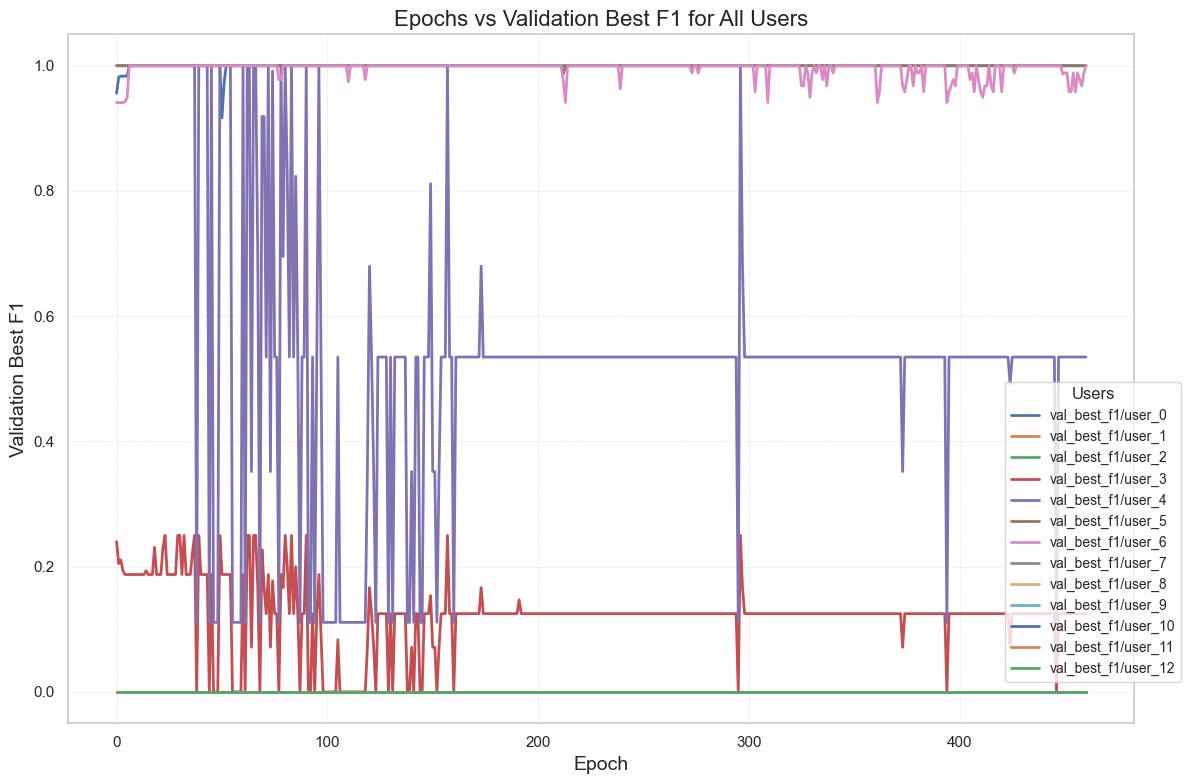

In [13]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user best_f1 column exists
best_f1_columns = [
    'val_best_f1/user_0', 'val_best_f1/user_1', 'val_best_f1/user_2', 
    'val_best_f1/user_3', 'val_best_f1/user_4', 'val_best_f1/user_5', 
    'val_best_f1/user_6', 'val_best_f1/user_7', 'val_best_f1/user_8', 
    'val_best_f1/user_9', 'val_best_f1/user_10', 'val_best_f1/user_11', 
    'val_best_f1/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in best_f1_columns):
    # Filter the DataFrame for 'epoch' and all best_f1 columns
    filtered_df = metrics_data[['epoch'] + best_f1_columns].dropna()

    # Set seaborn style
    sns.set(style="whitegrid")

    # Initialize the plot
    plt.figure(figsize=(12, 8))

    # Plot each user's best_f1 against epoch using seaborn's lineplot for smooth curves
    for best_f1_col in best_f1_columns:
        if best_f1_col in filtered_df.columns:
            sns.lineplot(x='epoch', y=best_f1_col, data=filtered_df, label=best_f1_col, lw=2)

    # Customize plot
    plt.title("Epochs vs Validation Best F1 for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Best F1", fontsize=14)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Move the legend to the bottom-right corner
    plt.legend(fontsize=10, loc='lower right', bbox_to_anchor=(1.05, 0.05), title="Users")

    # Log the image to wandb
    wandb.log({"Individual User Validation Best F1 (Smooth)": wandb.Image(plt)})

    # Show the plot
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

else:
    print("Either 'epoch' column or user best_f1 columns are not available in the DataFrame.")


# Best F1 score vs Epoch Subplot for each users

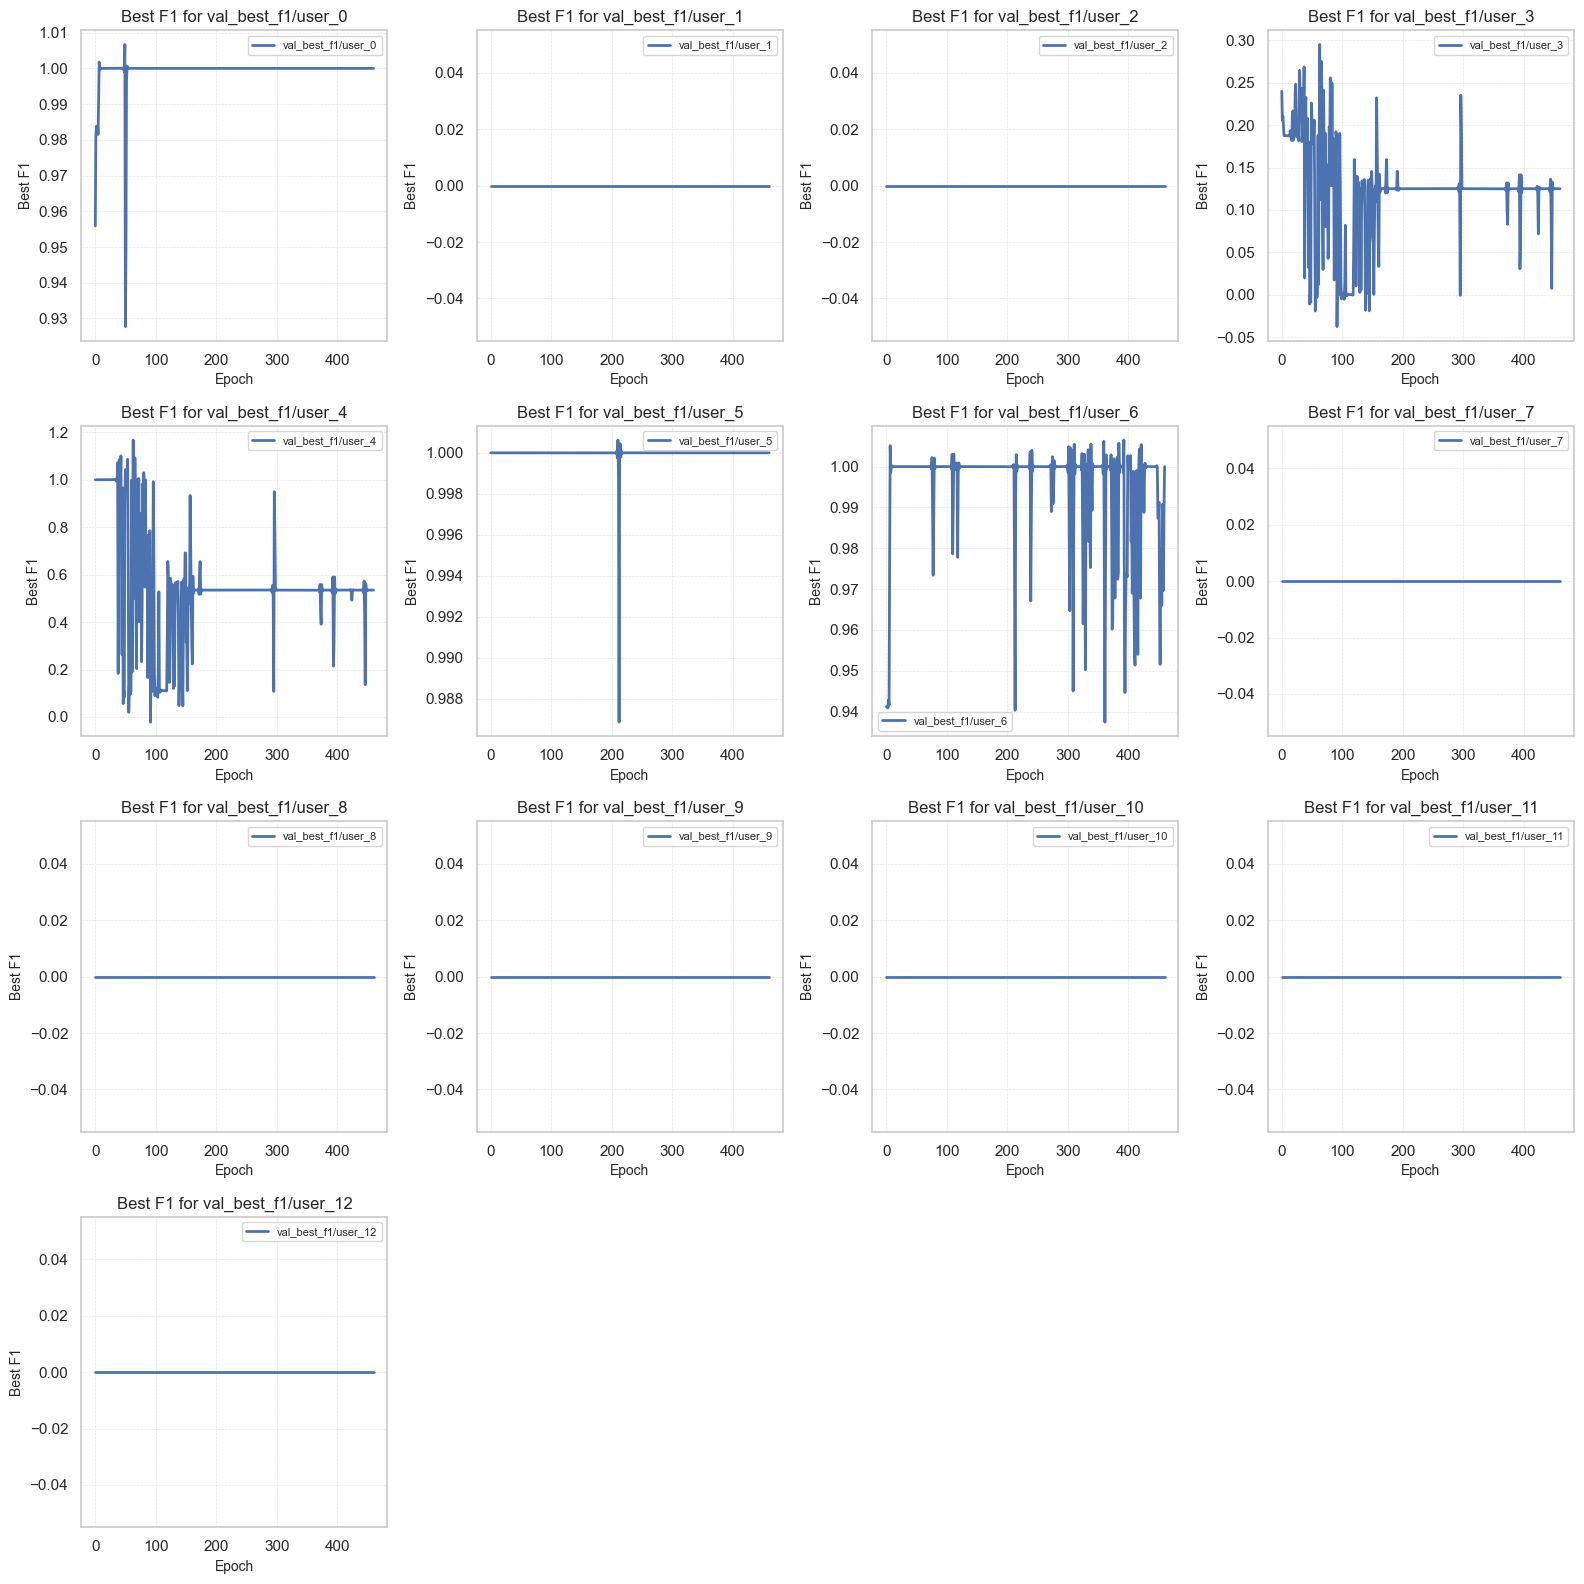

In [14]:
import numpy as np
from scipy.interpolate import CubicSpline

# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user best_f1 column exists
best_f1_columns = [
    'val_best_f1/user_0', 'val_best_f1/user_1', 'val_best_f1/user_2', 
    'val_best_f1/user_3', 'val_best_f1/user_4', 'val_best_f1/user_5', 
    'val_best_f1/user_6', 'val_best_f1/user_7', 'val_best_f1/user_8', 
    'val_best_f1/user_9', 'val_best_f1/user_10', 'val_best_f1/user_11', 
    'val_best_f1/user_12'
]

# Check if 'epoch' and any of the 'val_best_f1' columns are present
if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in best_f1_columns):
    # Filter the DataFrame for 'epoch' and all best_f1 columns
    filtered_df = metrics_data[['epoch'] + best_f1_columns].dropna()

    # Set seaborn style for better aesthetics
    sns.set(style="whitegrid")

    # Determine the number of subplots (one for each user)
    num_users = len(best_f1_columns)
    rows = num_users // 4 + (num_users % 4 > 0)  # 4 plots per row, adjust number of rows

    # Create the subplots
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
    
    # Flatten the axes array to easily iterate over it
    axes = axes.flatten()

    # Plot each user's best_f1 against epoch in a separate subplot
    for i, best_f1_col in enumerate(best_f1_columns):
        if best_f1_col in filtered_df.columns:
            # Extract the user best_f1 values
            x = filtered_df['epoch']
            y = filtered_df[best_f1_col]
        
            # Use cubic spline interpolation for smooth curves
            cs = CubicSpline(x, y, bc_type='natural')
        
            # Generate smooth values for plotting
            smooth_x = np.linspace(x.min(), x.max(), 500)  # More points for a smoother curve
            smooth_y = cs(smooth_x)
        
            # Plot the smooth line in the respective subplot
            axes[i].plot(smooth_x, smooth_y, lw=2, label=best_f1_col)
        
            # Customize the subplot
            axes[i].set_title(f"Best F1 for {best_f1_col}", fontsize=12)
            axes[i].set_xlabel("Epoch", fontsize=10)
            axes[i].set_ylabel("Best F1", fontsize=10)
            axes[i].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
            axes[i].legend(fontsize=8)

    # Hide unused subplots
    for j in range(len(best_f1_columns), len(axes)):
        axes[j].set_visible(False)

    # Adjust layout to avoid overlapping subplots
    plt.tight_layout()

    # Log the image to wandb
    wandb.log({"Individual User Validation Best F1 subplot": wandb.Image(fig)})

    # Show the plot
    plt.show()

else:
    print("Either 'epoch' column or user best_f1 columns are not available in the DataFrame.")


In [15]:
# Check if both 'epoch' and 'val_precision/user_1' columns exist
if 'epoch' in metrics_data.columns and 'val_precision/user_1' in metrics_data.columns:
    # Filter the DataFrame for 'epoch' and 'val_precision/user_1'
    filtered_df_user_1 = metrics_data[['epoch', 'val_precision/user_0', 'val_precision/user_1', 
                                       'val_precision/user_2', 'val_precision/user_3', 'val_precision/user_4', 
                                       'val_precision/user_5', 'val_precision/user_6', 'val_precision/user_7', 
                                       'val_precision/user_8', 'val_precision/user_9', 'val_precision/user_10', 
                                       'val_precision/user_11', 'val_precision/user_12']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_precision_user_1 = filtered_df_user_1.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch' and 'val_precision/user_1':\n", distinct_epochs_and_precision_user_1)
else:
    print("Either 'epoch' or 'val_precision/user_1' column is not available in the DataFrame.")


Distinct values of 'epoch' and 'val_precision/user_1':
        epoch  val_precision/user_0  val_precision/user_1  \
210      0.0              0.944444                   0.0   
422      1.0              1.000000                   0.0   
634      2.0              1.000000                   0.0   
846      3.0              1.000000                   0.0   
1058     4.0              1.000000                   0.0   
...      ...                   ...                   ...   
96882  456.0              1.000000                   0.0   
97094  457.0              1.000000                   0.0   
97306  458.0              1.000000                   0.0   
97518  459.0              1.000000                   0.0   
97730  460.0              1.000000                   0.0   

       val_precision/user_2  val_precision/user_3  val_precision/user_4  \
210                     0.0              0.230769                   1.0   
422                     0.0              0.173719                   1.0  

 # Precision vs Epoch (for each users)

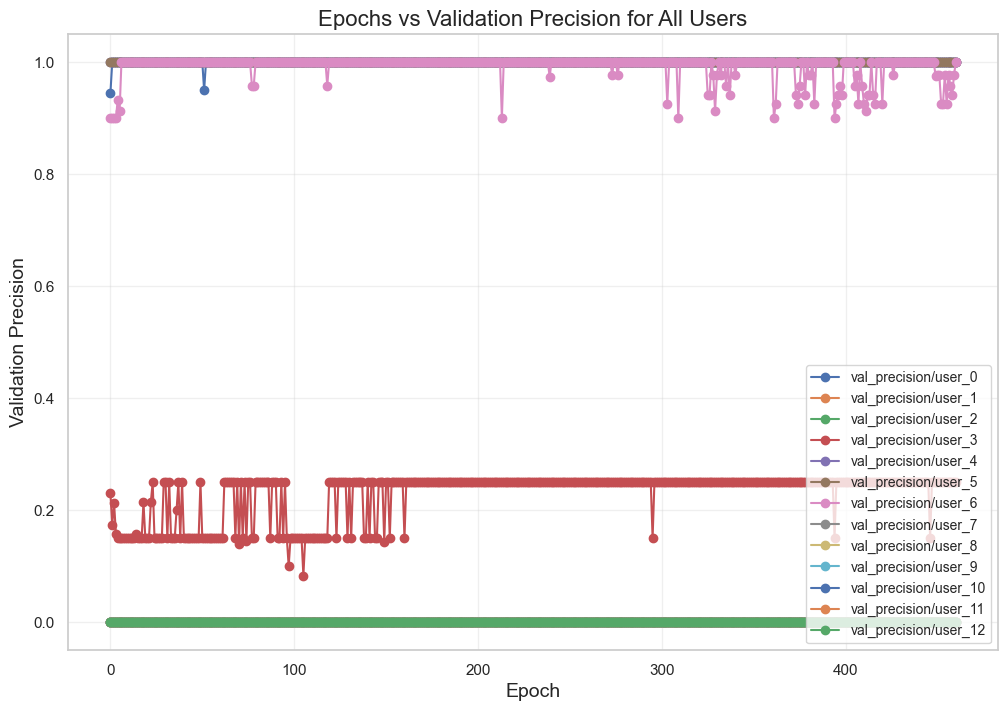

In [16]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user precision column exists
precision_columns = [
    'val_precision/user_0', 'val_precision/user_1', 'val_precision/user_2', 
    'val_precision/user_3', 'val_precision/user_4', 'val_precision/user_5', 
    'val_precision/user_6', 'val_precision/user_7', 'val_precision/user_8', 
    'val_precision/user_9', 'val_precision/user_10', 'val_precision/user_11', 
    'val_precision/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in precision_columns):
    # Filter the DataFrame for 'epoch' and all precision columns
    filtered_df = metrics_data[['epoch'] + precision_columns].dropna()
    
    # Plot each user's precision against epoch
    plt.figure(figsize=(12, 8))
    for precision_col in precision_columns:
        if precision_col in filtered_df.columns:
            plt.plot(filtered_df['epoch'], filtered_df[precision_col], marker='o', linestyle='-', label=precision_col)
    
    # Customize plot
    plt.title("Epochs vs Validation Precision for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Precision", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10, loc='lower right')
    wandb.log({"Individual User Validation Precision": wandb.Image(plt)})
    
    plt.show()
else:
    print("Either 'epoch' column or user precision columns are not available in the DataFrame.")


 # Precision vs Epoch (Smooth) for each users

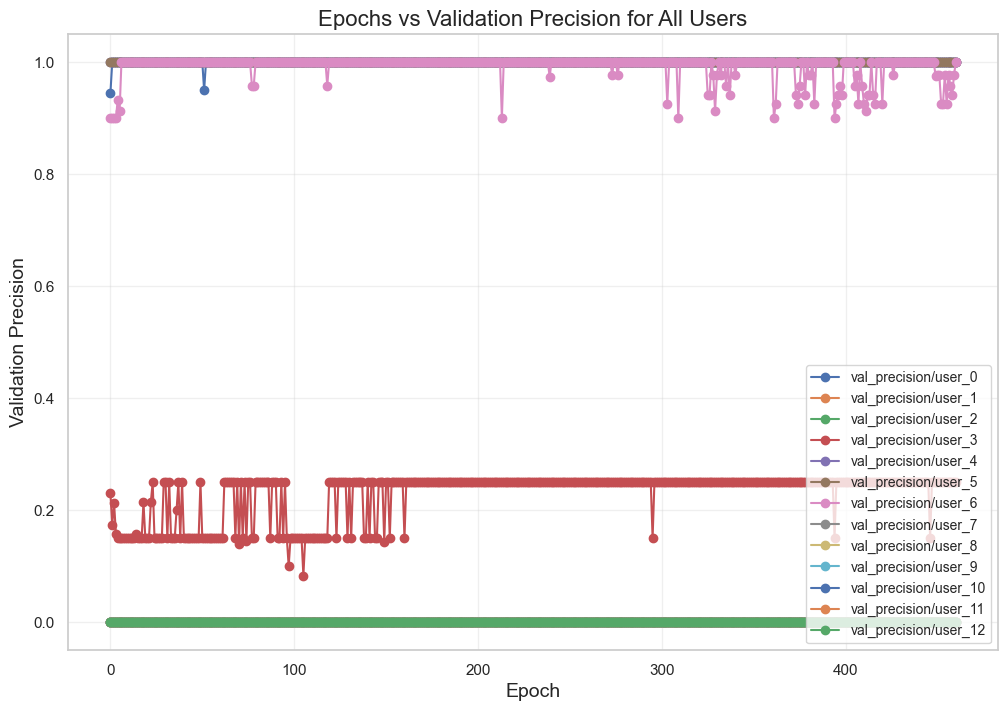

In [17]:
# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user precision column exists
precision_columns = [
    'val_precision/user_0', 'val_precision/user_1', 'val_precision/user_2', 
    'val_precision/user_3', 'val_precision/user_4', 'val_precision/user_5', 
    'val_precision/user_6', 'val_precision/user_7', 'val_precision/user_8', 
    'val_precision/user_9', 'val_precision/user_10', 'val_precision/user_11', 
    'val_precision/user_12'
]

if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in precision_columns):
    # Filter the DataFrame for 'epoch' and all precision columns
    filtered_df = metrics_data[['epoch'] + precision_columns].dropna()
    
    # Plot each user's precision against epoch
    plt.figure(figsize=(12, 8))
    for precision_col in precision_columns:
        if precision_col in filtered_df.columns:
            plt.plot(filtered_df['epoch'], filtered_df[precision_col], marker='o', linestyle='-', label=precision_col)
    
    # Customize plot
    plt.title("Epochs vs Validation Precision for All Users", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Validation Precision", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10, loc='lower right')
    wandb.log({"Individual User Validation Precision": wandb.Image(plt)})
    
    plt.show()
else:
    print("Either 'epoch' column or user precision columns are not available in the DataFrame.")


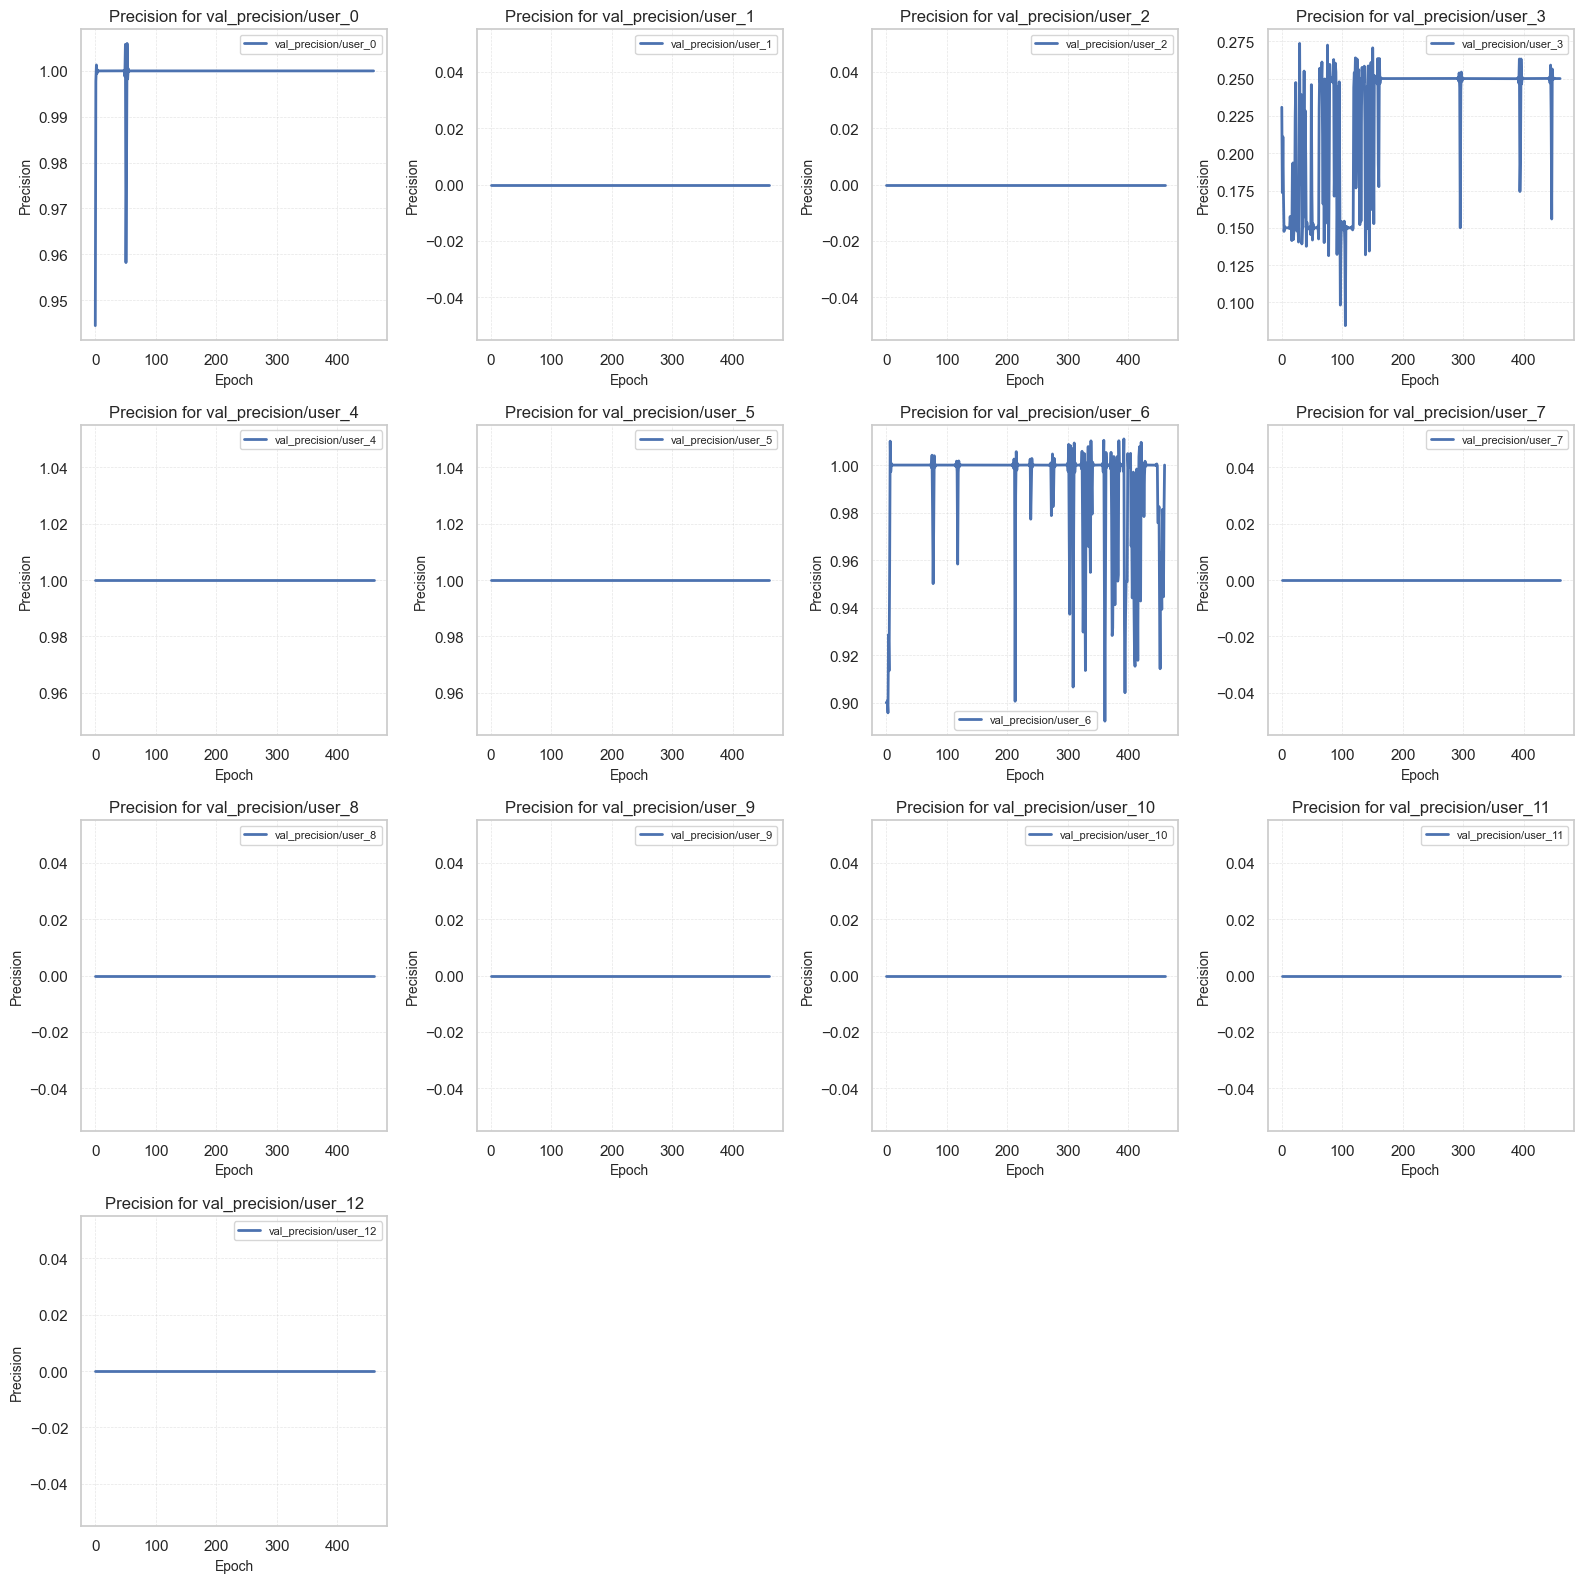

In [18]:
import numpy as np
from scipy.interpolate import CubicSpline

# Assuming the DataFrame is already loaded as metrics_data
# Check if 'epoch' exists and at least one user precision column exists
precision_columns = [
    'val_precision/user_0', 'val_precision/user_1', 'val_precision/user_2', 
    'val_precision/user_3', 'val_precision/user_4', 'val_precision/user_5', 
    'val_precision/user_6', 'val_precision/user_7', 'val_precision/user_8', 
    'val_precision/user_9', 'val_precision/user_10', 'val_precision/user_11', 
    'val_precision/user_12'
]

# Check if 'epoch' and at least one precision column are present
if 'epoch' in metrics_data.columns and any(col in metrics_data.columns for col in precision_columns):
    # Filter the DataFrame for 'epoch' and all precision columns
    filtered_df = metrics_data[['epoch'] + precision_columns].dropna()
    
    # Set seaborn style for better aesthetics
    sns.set(style="whitegrid")

    # Determine the number of subplots (one for each user)
    num_users = len(precision_columns)
    rows = num_users // 4 + (num_users % 4 > 0)  # 4 plots per row, adjust number of rows

    # Create the subplots
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
    
    # Flatten the axes array to easily iterate over it
    axes = axes.flatten()

    # Plot each user's precision against epoch in a separate subplot
    for i, precision_col in enumerate(precision_columns):
        if precision_col in filtered_df.columns:
            # Extract the user precision values
            x = filtered_df['epoch']
            y = filtered_df[precision_col]
        
            # Use cubic spline interpolation for smooth curves
            cs = CubicSpline(x, y, bc_type='natural')
        
            # Generate smooth values for plotting
            smooth_x = np.linspace(x.min(), x.max(), 500)  # More points for a smoother curve
            smooth_y = cs(smooth_x)
        
            # Plot the smooth line in the respective subplot
            axes[i].plot(smooth_x, smooth_y, lw=2, label=precision_col)
        
            # Customize the subplot
            axes[i].set_title(f"Precision for {precision_col}", fontsize=12)
            axes[i].set_xlabel("Epoch", fontsize=10)
            axes[i].set_ylabel("Precision", fontsize=10)
            axes[i].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
            axes[i].legend(fontsize=8)

    # Hide unused subplots
    for j in range(len(precision_columns), len(axes)):
        axes[j].set_visible(False)

    # Adjust layout to avoid overlapping subplots
    plt.tight_layout()

    # Log the image to wandb
    wandb.log({"Individual User Validation Precision Subplots": wandb.Image(fig)})

    # Show the plot
    plt.show()

else:
    print("Either 'epoch' column or user precision columns are not available in the DataFrame.")


In [19]:
wandb.finish()